<a href="https://colab.research.google.com/github/wijayafajar/Final-Task_ID-X-Partners_Data-Scientist_Muhammad-Wijaya-Fajar-Ramadhan/blob/main/Project_Rakamin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIBRARY

In [670]:
#Mengimport libraries yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE

# IMPORTING DATA

In [595]:
#Mengimport data yang akan diolah
data= pd.read_csv('loan_data_2007_2014 (2).csv', index_col=0)

# EXPLORING DATA

In [596]:
#Menampilkan informasi tentang data yang kita punya
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466285 entries, 0 to 466284
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           466285 non-null  int64  
 1   member_id                    466285 non-null  int64  
 2   loan_amnt                    466285 non-null  int64  
 3   funded_amnt                  466285 non-null  int64  
 4   funded_amnt_inv              466285 non-null  float64
 5   term                         466285 non-null  object 
 6   int_rate                     466285 non-null  float64
 7   installment                  466285 non-null  float64
 8   grade                        466285 non-null  object 
 9   sub_grade                    466285 non-null  object 
 10  emp_title                    438697 non-null  object 
 11  emp_length                   445277 non-null  object 
 12  home_ownership               466285 non-null  object 
 13  annu

In [597]:
#Menampilkan satu data secara acak
data.sample()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
126876,5757479,7189676,24000,24000,24000.0,60 months,23.28,680.44,F,F2,...,NaN,NaN,NaN,NaN,NaN,NaN,53000.0,NaN,NaN,NaN


In [598]:
#Menampilkan nilai unik dalam setiap variabel/kolom
data.nunique()

,0
id,466285
member_id,466285
loan_amnt,1352
funded_amnt,1354
funded_amnt_inv,9854
...,...
all_util,0
total_rev_hi_lim,14612
inq_fi,0
total_cu_tl,0


Dari hasil diatas dapat dipahami bahwa tidak ada id atau member_id yang duplikat, sehingga  setiap baris sudah mewakili satu individu.

Kemudian, akan dilakukan pembuangan fitur-fitur yang kurang berguna dilakukan. Contohnya seperti fitur yang merupakan id, berupa free text, nilai (NULL), dsb.

In [599]:
#Membuat fungsi untuk membuang variabel yang kurang berguna
cols_to_drop = [
    # unique id
    'id'
    , 'member_id'

    # free text
    , 'url'
    , 'desc'

    # nilai null / constant / others
    , 'zip_code'
    , 'annual_inc_joint'
    , 'dti_joint'
    , 'verification_status_joint'
    , 'open_acc_6m'
    , 'open_il_6m'
    , 'open_il_12m'
    , 'open_il_24m'
    , 'mths_since_rcnt_il'
    , 'total_bal_il'
    , 'il_util'
    , 'open_rv_12m'
    , 'open_rv_24m'
    , 'max_bal_bc'
    , 'all_util'
    , 'inq_fi'
    , 'total_cu_tl'
    , 'inq_last_12m'

    # expert judgment
    , 'sub_grade'
]

In [600]:
#Membuang variabel yang kurang berguna dari fungsi diatas
data_new = data.drop(cols_to_drop, axis=1)

In [601]:
#Menampilkan 10 data terbaru secara acak
data_new.sample(10)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,...,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
885,4000,4000,4000.0,36 months,8.90,127.02,A,self,3 years,MORTGAGE,...,NaN,Dec-14,0.0,NaN,1,INDIVIDUAL,0.0,NaN,NaN,NaN
76082,10000,10000,10000.0,36 months,11.99,332.10,B,feeder driver,10+ years,MORTGAGE,...,Feb-16,Jan-16,0.0,9.0,1,INDIVIDUAL,0.0,0.0,228148.0,13100.0
233718,17000,17000,17000.0,60 months,8.67,350.18,B,Medical Laboratory Scientist,7 years,MORTGAGE,...,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,0.0,0.0,105023.0,39500.0
337931,10750,10750,10725.0,36 months,15.61,375.88,D,Live in Caregiver and Legal Guardian,2 years,RENT,...,Feb-16,Jan-16,0.0,60.0,1,INDIVIDUAL,0.0,0.0,10634.0,11500.0
118207,7500,7500,7500.0,36 months,11.55,247.50,B,Marvin Windows and Doors,10+ years,MORTGAGE,...,Feb-16,Jan-16,0.0,35.0,1,INDIVIDUAL,0.0,0.0,98994.0,24300.0
168308,8000,8000,8000.0,36 months,14.33,274.71,C,Volunteers of America,5 years,RENT,...,NaN,Oct-15,0.0,NaN,1,INDIVIDUAL,0.0,0.0,7032.0,17800.0
13862,12000,12000,12000.0,60 months,17.49,301.41,D,Emergency Medicine Physicians,10+ years,MORTGAGE,...,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,0.0,NaN,NaN,NaN
93317,35000,35000,35000.0,60 months,21.15,949.83,E,CRSC,5 years,OWN,...,Feb-16,Jan-16,0.0,79.0,1,INDIVIDUAL,0.0,0.0,63274.0,41000.0
246293,18500,18500,18500.0,60 months,17.86,468.38,D,Director New View industries,10+ years,RENT,...,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,0.0,999.0,127172.0,37100.0
62216,11000,11000,11000.0,36 months,7.90,344.20,A,Product Analyst,10+ years,RENT,...,NaN,Jan-16,0.0,42.0,1,INDIVIDUAL,0.0,0.0,84837.0,12100.0


# MENENTUKAN VARIABEL TARGET(LABELLING)
Fokus utama dalam pemodelan risiko kredit (credit risk modeling) adalah memprediksi kemampuan seseorang dalam melunasi pinjamannya. Oleh karena itu, kita harus memilih variabel target yang secara akurat merepresentasikan kemampuan bayar tersebut. Pada dataset ini, kolom loan_status dipilih sebagai variabel target (label) karena data di dalamnya menunjukkan rekam jejak performa pembayaran kredit nasabah secara historis.

In [602]:
#Akan dilihat proposi nilai dari variabel loan_status
data_new.loan_status.value_counts(normalize=True)*100

,proportion
loan_status,
Current,48.087757
Fully Paid,39.619332
Charged Off,9.109236
Late (31-120 days),1.479782
In Grace Period,0.674695
Does not meet the credit policy. Status:Fully Paid,0.426349
Late (16-30 days),0.261214
Default,0.178432
Does not meet the credit policy. Status:Charged Off,0.163205


Berdasarkan tabel di atas, variabel loan_status memiliki beberapa nilai kategori dengan urutan proporsi sebagai berikut:

Current: Pembayaran berjalan lancar.

Fully Paid: Pembayaran pinjaman sudah lunas.

Charged Off: Pembayaran macet sehingga dihapusbukukan oleh pihak bank.

Late (31-120 days): Pembayaran terlambat dilakukan antara 31 hingga 120 hari.

In Grace Period: Pembayaran sedang dalam masa tenggang.

Does not meet the credit policy. Status:Fully Paid: Pinjaman lunas, namun riwayatnya tidak memenuhi persyaratan kebijakan kredit saat ini.

Late (16-30 days): Pembayaran terlambat dilakukan antara 16 hingga 30 hari.

Default: Pembayaran macet / gagal bayar.

Does not meet the credit policy. Status:Charged Off: Pinjaman dihapusbukukan dan tidak memenuhi persyaratan kebijakan kredit saat ini.

Dari definisi status di atas, kita dapat melabeli masing-masing individu ke dalam dua kategori, yaitu bad loan (peminjam berisiko/buruk) atau good loan (peminjam yang baik). Meskipun kriteria penentuan good dan bad loan dapat bervariasi tergantung pada kebijakan bisnis, pada proyek ini, keterlambatan pembayaran di atas 30 hari beserta status yang lebih buruk dari itu akan diklasifikasikan sebagai bad loan.

In [603]:
#Dibuat fungsi bad status sesuai yang saya klasifikasi bagi yang memiliki keterlambatan diatas 30 hari dan yg lebih buruk
bad_status = [
    'Charged Off'
    , 'Default'
    , 'Does not meet the credit policy. Status:Charged Off'
    , 'Late (31-120 days)'
]

data_new['bad_flag'] = np.where(data_new['loan_status'].isin(bad_status), 1, 0)

In [604]:
#Dicek proporsi data antara bad_flag dan good_flag
data_new['bad_flag'].value_counts(normalize=True)*100

,proportion
bad_flag,
0,89.069346
1,10.930654


Berdasarkan hasil flagging di atas, terlihat jelas bahwa jumlah nasabah dengan kategori bad loan (angka 1) jauh lebih sedikit dibandingkan good loan (angka 0). Kondisi ini mengonfirmasi bahwa kita sedang menangani masalah imbalanced dataset (data yang tidak seimbang). Terakhir, sebagai langkah pembersihan, kita harus menghapus (drop) kolom asli loan_status karena informasinya sudah sepenuhnya diwakili oleh kolom target yang baru.

In [605]:
#Membuang variabel/kolom loan_status
data_new.drop('loan_status', axis=1, inplace=True)

# DATA CLEANING, DATA PRE-PROCESSING, DATA FEATURE ENGINEERING
Akan dilakukan pembersihan/modifikasi beberapa fitur ke dalam format yang dapat digunakan untuk modeling.

# Variabel/Kolom : Term
Akan dimodifikasi variabel term. Contoh: 60 months -> 60



In [606]:
#Dicek nilai dari kolom term
data_new['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [607]:
#Menghapus months dan juga mengganti tipe data dari string/teks jadi float/numerik
data_new['term_int'] = data_new['term'].str.replace(' months', '')
data_new['term_int'] = data_new['term_int'].astype(float)

In [608]:
#Menghapus variabel term karna sudah diganti dengan variabel term_int
data_new.drop('term', axis=1, inplace=True)

# Variabel/Kolom : emp_length
Akan dimodifikasi variabel emp_length. Contoh: 1 years -> 1

In [609]:
#Dicek nilai dari kolom emp_lenght
data_new['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [610]:
#Menghapus + years, < 1 year, years, year dan juga mengganti tipe data dari string/teks jadi float/numerik
data_new['emp_length_int'] = data_new['emp_length'].str.replace('+ years', '')
data_new['emp_length_int'] = data_new['emp_length_int'].str.replace('< 1 year', str(0))
data_new['emp_length_int'] = data_new['emp_length_int'].str.replace(' years', '')
data_new['emp_length_int'] = data_new['emp_length_int'].str.replace(' year', '')
data_new['emp_length_int'] = data_new['emp_length_int'].astype(float)

In [611]:
#Menghapus variabel emp_lenght karna sudah diganti dengan variabel emp_lenght_int
data.drop('emp_length', axis=1, inplace=True)

# Variabel/Kolom : earliest_cr_line
Kolom earliest_cr_line awalnya memiliki format bulan dan tahun. Kita akan mengubahnya menjadi fitur durasi, yaitu menghitung sudah berapa lama waktu berlalu sejak tanggal pada kolom tersebut.

Pada umumnya, perhitungan selisih waktu seperti ini menggunakan patokan tanggal hari ini (today). Namun, mengingat dataset yang kita gunakan adalah data historis dari tahun 2007 hingga 2014, menggunakan waktu saat ini tentu menjadi kurang relevan. Oleh karena itu, kita akan menggunakan tanggal referensi yang lebih masuk akal dengan konteks data, yaitu 1 Desember 2017 (2017-12-01).

In [612]:
#Menampilkan data variabel earliest_cr_line
data_new['earliest_cr_line'].head()

,earliest_cr_line
0,Jan-85
1,Apr-99
2,Nov-01
3,Feb-96
4,Jan-96


In [613]:
#Mengkonversi tanggal dan menampilkan hasil konversinya 5 baris
data_new['earliest_cr_line_date'] = pd.to_datetime(data_new['earliest_cr_line'], format='%b-%y')
data_new['earliest_cr_line_date'].head(5)

,earliest_cr_line_date
0,1985-01-01
1,1999-04-01
2,2001-11-01
3,1996-02-01
4,1996-01-01


In [614]:
#Menghitung selisih waktu dengan tanggal pembuatan kartu kredit (dalam bulan) dan menampilkan 3 baris data terupdatenya
data_new['mths_since_earliest_cr_line'] = round((pd.to_datetime('2017-12-01') - data_new['earliest_cr_line_date']).dt.days / 30.4375)
data_new['mths_since_earliest_cr_line'].head(3)

,mths_since_earliest_cr_line
0,395.0
1,224.0
2,193.0


In [615]:
#Menampilkan informasi data mths_since_earliest_cr_line
data_new['mths_since_earliest_cr_line'].describe()

,mths_since_earliest_cr_line
count,466256.000000
mean,239.482430
std,93.974829
min,-612.000000
25%,183.000000
50%,225.000000
75%,285.000000
max,587.000000


Setelah dicek ternyata ada data yang negatif.

In [616]:
data_new[data_new['mths_since_earliest_cr_line']<0][['earliest_cr_line', 'earliest_cr_line_date', 'mths_since_earliest_cr_line']].head(3)

,earliest_cr_line,earliest_cr_line_date,mths_since_earliest_cr_line
1580,Sep-62,2062-09-01,-537.0
1770,Sep-68,2068-09-01,-609.0
2799,Sep-64,2064-09-01,-561.0


Setelah diselidiki, nilai negatif ini muncul karena kesalahan interpretasi pada fungsi Python. Format tahun dua digit seperti '62' yang seharusnya merujuk pada tahun 1962, justru dibaca sebagai tahun 2062. Akibatnya, perhitungan selisih waktunya menjadi minus.

Sebenarnya kita bisa saja membuat langkah preprocessing tambahan yang rumit untuk memundurkan tahun 2062 kembali menjadi 1962. Namun, sebagai pendekatan yang lebih praktis, saya akan mengubah semua nilai negatif tersebut menjadi nilai maksimum dari kolom durasi ini. Pendekatan ini sangat masuk akal secara logika bisnis; nasabah dengan rekam jejak dari tahun 1900-an adalah mereka yang memiliki riwayat kredit paling tua. Oleh karena itu, menggantinya dengan nilai durasi bulan terbesar adalah hal yang sangat relevan.

In [617]:
#Menghapus durasi yang minus dan diganti dengan nilai durasi yang paling besar
data_new.loc[data_new['mths_since_earliest_cr_line']<0, 'mths_since_earliest_cr_line'] = data_new['mths_since_earliest_cr_line'].max()

In [618]:
#Menghapus variabel earliest_cr_line dan earliest_cr_line_date
data_new.drop(['earliest_cr_line', 'earliest_cr_line_date'], axis=1, inplace=True)

# Variabel/Kolom : issue_d
cara dan pengerjaannya analog dengan earliest_cr_line

In [619]:
#Menghitung selisih waktu dengan tanggal pencairan pinjaman (dalam bulan)
data_new['issue_d_date'] = pd.to_datetime(data_new['issue_d'], format='%b-%y')
data_new['mths_since_issue_d'] = round((pd.to_datetime('2017-12-01') - data_new['issue_d_date']).dt.days / 30.4375)

In [620]:
#Menampilkan informasi data untuk mengecek apakah ada anomali
data_new['mths_since_issue_d'].describe()

,mths_since_issue_d
count,466285.000000
mean,51.255187
std,14.340154
min,36.000000
25%,41.000000
50%,47.000000
75%,57.000000
max,126.000000


In [621]:
#Menghapus variabel issue_d dan issue_d_date
data_new.drop(['issue_d', 'issue_d_date'], axis=1, inplace=True)

# Variabel/Kolom : last_pymnt_d
cara dan pengerjaannya analog dengan earliest_cr_line

In [622]:
#Menghitung selisih waktu dengan tanggal berapa lama nasabah tidak melakukan pembayaran(dalam bulan)
data_new['last_pymnt_d_date'] = pd.to_datetime(data_new['last_pymnt_d'], format='%b-%y')
data_new['mths_since_last_pymnt_d'] = round((pd.to_datetime('2017-12-01') - data_new['last_pymnt_d_date']).dt.days / 30.4375)

In [623]:
#Menampilkan informasi data untuk mengecek apakah ada anomali
data_new['mths_since_last_pymnt_d'].describe()

,mths_since_last_pymnt_d
count,465909.000000
mean,31.294369
std,12.809898
min,23.000000
25%,23.000000
50%,24.000000
75%,35.000000
max,120.000000


In [624]:
#Menghapus variabel last_pymnt_d dan last_pymnt_d_date
data_new.drop(['last_pymnt_d', 'last_pymnt_d_date'], axis=1, inplace=True)

# Variabel/Kolom : next_pymnt_d
cara dan pengerjaannya analog dengan earliest_cr_line

In [625]:
#Menghitung selisih waktu dengan tanggal jadwal pembayaran selanjutnya(dalam bulan)
data_new['next_pymnt_d_date'] = pd.to_datetime(data_new['next_pymnt_d'], format='%b-%y')
data_new['mths_since_next_pymnt_d'] = round((pd.to_datetime('2017-12-01') - data_new['next_pymnt_d_date']).dt.days / 30.4375)

In [626]:
#Menampilkan informasi data untuk mengecek apakah ada anomali
data_new['mths_since_next_pymnt_d'].describe()

,mths_since_next_pymnt_d
count,239071.000000
mean,22.738136
std,6.082298
min,21.000000
25%,22.000000
50%,22.000000
75%,22.000000
max,120.000000


In [627]:
#Menghapus variabel next_pymnt_d dan next_pymnt_d_date
data_new.drop(['next_pymnt_d', 'next_pymnt_d_date'], axis=1, inplace=True)

# Variabel/Kolom : last_credit_pull_d
cara dan pengerjaannya analog dengan earliest_cr_line

In [628]:
#Menghitung selisih waktu dengan tanggal pengecekan kredit terakhir(dalam bulan)
data_new['last_credit_pull_d_date'] = pd.to_datetime(data_new['last_credit_pull_d'], format='%b-%y')
data_new['mths_since_last_credit_pull_d'] = round((pd.to_datetime('2017-12-01') - data_new['last_credit_pull_d_date']).dt.days / 30.4375)

In [629]:
#Menampilkan informasi data untuk mengecek apakah ada anomali
data_new['mths_since_last_credit_pull_d'].describe()

,mths_since_last_credit_pull_d
count,466243.000000
mean,27.045588
std,9.636423
min,23.000000
25%,23.000000
50%,23.000000
75%,25.000000
max,127.000000


In [630]:
#Menghapus variabel last_credit_pull_d dan last_credit_pull_d_date
data_new.drop(['last_credit_pull_d', 'last_credit_pull_d_date'], axis=1, inplace=True)

# EXPLORATORY DATA ANALYSIS

<Axes: >

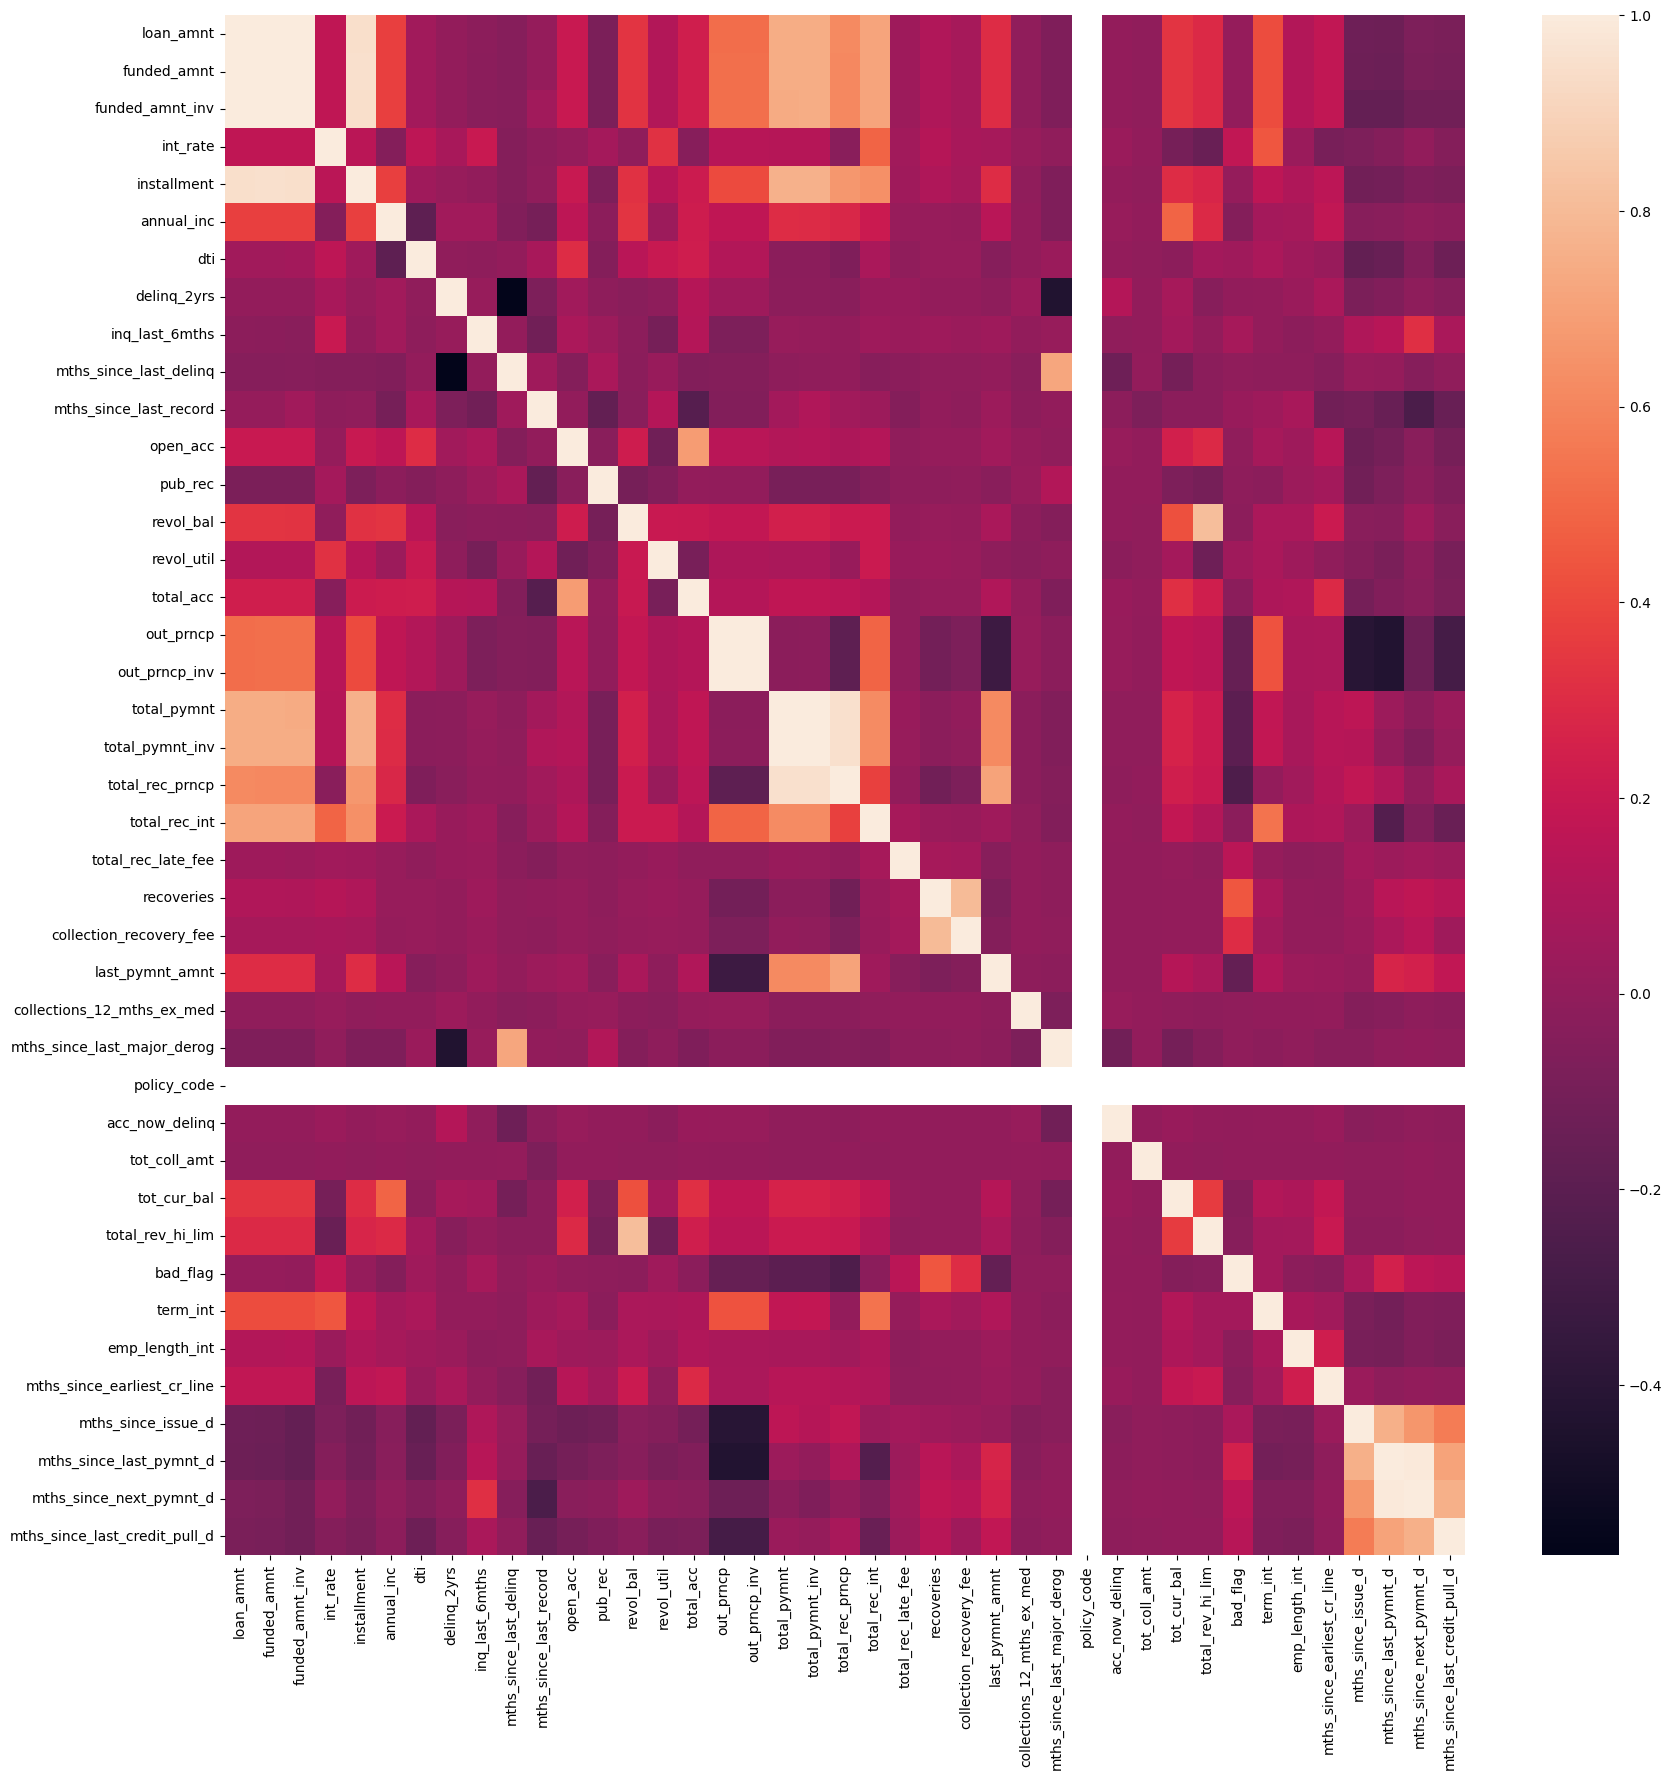

In [631]:
#Memvisualisasikan correlation antar variabel
plt.figure(figsize=(20,20))
sns.heatmap(data_new.select_dtypes(include=np.number).corr())

Pada tahap visualisasi ini, kita mencari pasangan fitur yang memiliki korelasi terlalu tinggi (saling tumpang tindih informasinya). Jika ditemukan fitur yang terlalu mirip, kita cukup mempertahankan salah satunya saja dan membuang sisanya agar model tidak kebingungan. Memang tidak ada aturan baku mengenai batas angka korelasi ini, namun secara umum, angka 0.7 sering dijadikan patokan standar untuk menentukan apakah dua fitur memiliki korelasi yang tinggi.

In [632]:
#Membuat fungsi untuk mencari variabel yang memiliki korelasi > 0.7
corr_matrix = data_new.select_dtypes(include=np.number).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool_))
to_drop_hicorr = [column for column in upper.columns if any(upper[column] > 0.7)]

In [633]:
#menampilkan kolom yang akan dibuang
to_drop_hicorr

['funded_amnt',
 'funded_amnt_inv',
 'installment',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'mths_since_last_major_derog',
 'total_rev_hi_lim',
 'mths_since_last_pymnt_d',
 'mths_since_next_pymnt_d',
 'mths_since_last_credit_pull_d']

In [634]:
#membuang kolom yang korelasi >0.7
data_new.drop(to_drop_hicorr, axis=1, inplace=True)

In [635]:
# melakukan check fitur kategorik include object
data_new.select_dtypes(include='object').nunique()

,0
grade,7
emp_title,205475
emp_length,11
home_ownership,6
verification_status,3
pymnt_plan,2
purpose,14
title,63098
addr_state,50
initial_list_status,2


Menghapus fitur non-informatif yang terdiri dari variabel dengan nilai tunggal serta fitur kategorikal dengan jumlah nilai unik yang terlalu besar (high cardinality).

In [636]:
#menghapus variabel yang memiliki kardinalitas yang terlalu besar dan yang memiliki kardinalitas tunggal
data_new.drop(['emp_title', 'title', 'application_type'], axis=1, inplace=True)

In [637]:
# melakukan check fitur kategorik exclude object
data_new.select_dtypes(exclude='object').nunique()

,0
loan_amnt,1352
int_rate,506
annual_inc,31901
dti,3997
delinq_2yrs,24
inq_last_6mths,28
mths_since_last_delinq,145
mths_since_last_record,123
open_acc,62
pub_rec,26


selain di tipe data object, di tipe data object juga memiliki kardinalitas tunggal sehingga akan dihapus


In [638]:
#menghapus variabel yang memiliki kardinalitas tunggal
data_new.drop(['policy_code'], axis=1, inplace=True)

In [639]:
#melihat proporsi data
for col in data_new.select_dtypes(include='object').columns.tolist():
    print(data_new[col].value_counts(normalize=True)*100)
    print('\n')

grade
B    29.365946
C    26.870476
D    16.489486
A    16.056060
E     7.668486
F     2.837106
G     0.712440
Name: proportion, dtype: float64


emp_length
10+ years    33.697900
2 years       9.291520
3 years       8.218704
< 1 year      8.144369
5 years       6.911204
1 year        6.652488
4 years       6.293386
7 years       5.879486
6 years       5.864215
8 years       5.029454
9 years       4.017275
Name: proportion, dtype: float64


home_ownership
MORTGAGE    50.586015
RENT        40.420129
OWN          8.943886
OTHER        0.039032
NONE         0.010723
ANY          0.000214
Name: proportion, dtype: float64


verification_status
Verified           36.041262
Source Verified    32.167666
Not Verified       31.791072
Name: proportion, dtype: float64


pymnt_plan
n    99.99807
y     0.00193
Name: proportion, dtype: float64


purpose
debt_consolidation    58.804165
credit_card           22.337626
home_improvement       5.691155
other                  5.080584
major_purchase       

Variabel yang memiliki distribusi nilai tidak seimbang secara ekstrem akan dieliminasi, karena minimnya variabilitas informasi yang diberikan oleh fitur tersebut terhadap model.

In [640]:
#menghapus data yang memiliki distribusi tidak seimbang yang paling ekstrem
data_new.drop('pymnt_plan', axis=1, inplace=True)

# MISSING VALUE

In [641]:
#mengecek data yang hilang
check_missing = data_new.isnull().sum() * 100 / data_new.shape[0]
check_missing[check_missing > 0].sort_values(ascending=False)

,0
mths_since_last_record,86.566585
mths_since_last_delinq,53.690554
tot_coll_amt,15.071469
tot_cur_bal,15.071469
emp_length,4.505399
emp_length_int,4.505399
revol_util,0.072917
collections_12_mths_ex_med,0.031097
delinq_2yrs,0.006219
pub_rec,0.006219


setelah dicek ada data yang hilang lebih dari 75%, sehingga variabel yang memiliki data hilang > 75% akan dihapus

In [642]:
#menghapus data yang missing >75%
data_new.drop('mths_since_last_record', axis=1, inplace=True)

In [643]:
#mengisi nilai yang kosong pada tiap variabel dengan 0,rata2, dan -1
data_new['annual_inc'].fillna(data_new['annual_inc'].mean(), inplace=True)
data_new['mths_since_earliest_cr_line'].fillna(0, inplace=True)
data_new['acc_now_delinq'].fillna(0, inplace=True)
data_new['total_acc'].fillna(0, inplace=True)
data_new['pub_rec'].fillna(0, inplace=True)
data_new['open_acc'].fillna(0, inplace=True)
data_new['inq_last_6mths'].fillna(0, inplace=True)
data_new['delinq_2yrs'].fillna(0, inplace=True)
data_new['collections_12_mths_ex_med'].fillna(0, inplace=True)
data_new['revol_util'].fillna(0, inplace=True)
data_new['emp_length_int'].fillna(0, inplace=True)
data_new['tot_cur_bal'].fillna(0, inplace=True)
data_new['tot_coll_amt'].fillna(0, inplace=True)
data_new['mths_since_last_delinq'].fillna(-1, inplace=True)

# FEATURE SCALING AND TRANSFORMATION

In [644]:
#mencari kolom yang bertipe teks
categorical_cols = [col for col in data_new.select_dtypes(include='object').columns.tolist()]

In [645]:
#melakukan transformasi nilai ke nilai biner
onehot = pd.get_dummies(data_new[categorical_cols], drop_first=True, dtype=int)
onehot.head()

,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,emp_length_10+ years,emp_length_2 years,emp_length_3 years,emp_length_4 years,...,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY,initial_list_status_w
0,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


selanjutnya dilakukan standardisasi dengan standardscaler

In [646]:
#melakukan pemisahan kolom numerik dari dataset
numerical_cols = [col for col in data_new.columns if col not in categorical_cols and col != 'bad_flag']

In [647]:
#melakukan standardisasi pada variabel numerik dan menampilkan haislnya
ss = StandardScaler()
std = pd.DataFrame(ss.fit_transform(data_new[numerical_cols]), columns=numerical_cols)
std.head()

,loan_amnt,int_rate,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,...,total_rec_late_fee,recoveries,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,term_int,emp_length_int,mths_since_earliest_cr_line,mths_since_issue_d
0,-1.124392,-0.729587,-0.896551,1.328632,-0.357012,0.178920,-0.708792,-1.641166,-0.31429,-0.124888,...,-0.123464,-0.154549,-0.083608,-0.058307,-0.012089,-0.792648,-0.616225,1.138605,1.764941,1.446626
1,-1.426088,0.330634,-0.787387,-2.065791,-0.357012,3.843328,-0.708792,-1.641166,-0.31429,-0.703378,...,-0.123464,0.057470,-0.083608,-0.058307,-0.012089,-0.792648,1.622784,-1.523744,-0.212426,1.446626
2,-1.438156,0.488979,-1.110294,-1.082491,-0.357012,1.095022,-0.708792,-1.841641,-0.31429,-0.642003,...,-0.123464,-0.154549,-0.083608,-0.058307,-0.012089,-0.792648,-0.616225,1.138605,-0.570896,1.446626
3,-0.521001,-0.077850,-0.438063,0.354248,-0.357012,0.178920,0.860811,-0.237839,-0.31429,-0.514224,...,3.099264,-0.154549,-0.083608,-0.058307,-0.012089,-0.792648,-0.616225,1.138605,0.226989,1.446626
4,-1.365749,-0.261438,0.122311,0.091865,-0.357012,-0.737182,0.991612,0.764538,-0.31429,0.558748,...,-0.123464,-0.154549,-0.083608,-0.058307,-0.012089,-0.792648,1.622784,-1.257509,0.238553,1.446626


In [648]:
#selanjutnya menggabungkan kembali yang setelah variabel2 yang telah di transformasi
data_model = pd.concat([onehot, std, data_new[['bad_flag']]], axis=1)

# DATA MODELLING

In [686]:
# 1. Splitting yang sudah kamu buat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. TAMBAHKAN SMOTE DI SINI
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Cek hasilnya (Opsional)
print(f"Sebelum SMOTE: {y_train.value_counts()}")
print(f"Sesudah SMOTE: {y_train_res.value_counts()}")

Sebelum SMOTE: bad_flag
0    332250
1     40778
Name: count, dtype: int64
Sesudah SMOTE: bad_flag
0    332250
1    332250
Name: count, dtype: int64


In [673]:
#mengecek ukuran dataset yang akan di training
X_train_res.shape, X_test.shape

((664500, 109), (93257, 109))

**MODEL RANDOM FOREST**

In [674]:
#melatih model random forest dengan kedalaman maksimal 4 tingkat untuk mengklasifikasikan status risiko peminjam berdasarkan fitur-fitur yang tersedia
rfc = RandomForestClassifier(max_depth=4)
rfc.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=4)

In [675]:
#untuk mencari tahu variabel mana yang paling berpengaruh dalam model yang dilatih
arr_feature_importances = rfc.feature_importances_
arr_feature_names = X_train_res.columns.values

df_feature_importance = pd.DataFrame(index=range(len(arr_feature_importances)), columns=['feature', 'importance'])
df_feature_importance['feature'] = arr_feature_names
df_feature_importance['importance'] = arr_feature_importances
df_all_features = df_feature_importance.sort_values(by='importance', ascending=False)
df_all_features

,feature,importance
100,recoveries,0.416492
98,out_prncp,0.159785
87,int_rate,0.060208
85,initial_list_status_w,0.052598
108,mths_since_issue_d,0.043159
...,...,...
78,addr_state_UT,0.000000
84,addr_state_WY,0.000000
82,addr_state_WI,0.000000
83,addr_state_WV,0.000000


In [676]:
#mempersiapkan data evaluasi
y_pred_proba = rfc.predict_proba(X_test)[:][:,1]

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=['y_actual']), pd.DataFrame(y_pred_proba, columns=['y_pred_proba'])], axis=1)
df_actual_predicted.index = y_test.index

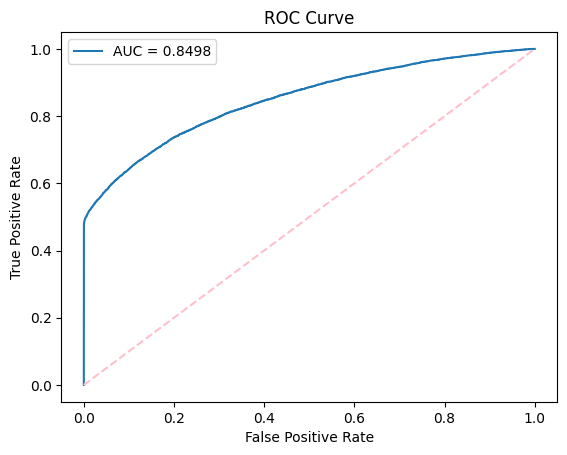

In [687]:
#memvisualisasikan performa model
fpr, tpr, tr = roc_curve(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])
auc = roc_auc_score(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])

plt.plot(fpr, tpr, label='AUC = %0.4f' %auc)
plt.plot(fpr, fpr, linestyle = '--', color='PINK')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

In [688]:
#Melakukan kalkulasi cumulative percentage untuk kategori aktual terhadap prediksi probabilitas
df_actual_predicted = df_actual_predicted.sort_values('y_pred_proba')
df_actual_predicted = df_actual_predicted.reset_index()

df_actual_predicted['Cumulative N Population'] = df_actual_predicted.index + 1
df_actual_predicted['Cumulative N Bad'] = df_actual_predicted['y_actual'].cumsum()
df_actual_predicted['Cumulative N Good'] = df_actual_predicted['Cumulative N Population'] - df_actual_predicted['Cumulative N Bad']
df_actual_predicted['Cumulative Perc Population'] = df_actual_predicted['Cumulative N Population'] / df_actual_predicted.shape[0]
df_actual_predicted['Cumulative Perc Bad'] = df_actual_predicted['Cumulative N Bad'] / df_actual_predicted['y_actual'].sum()
df_actual_predicted['Cumulative Perc Good'] = df_actual_predicted['Cumulative N Good'] / (df_actual_predicted.shape[0] - df_actual_predicted['y_actual'].sum())
df_actual_predicted.head()

,level_0,index,y_actual,y_pred_proba,Cumulative N Population,Cumulative N Bad,Cumulative N Good,Cumulative Perc Population,Cumulative Perc Bad,Cumulative Perc Good
0,0,284281,0,0.184739,1,0,1,0.000011,0.0,0.000012
1,1,246153,0,0.185519,2,0,2,0.000021,0.0,0.000024
2,2,254206,0,0.185695,3,0,3,0.000032,0.0,0.000036
3,3,256941,0,0.185954,4,0,4,0.000043,0.0,0.000048
4,4,249566,0,0.186451,5,0,5,0.000054,0.0,0.000060


Text(0.5, 1.0, 'Kolmogorov-Smirnov:  0.5454')

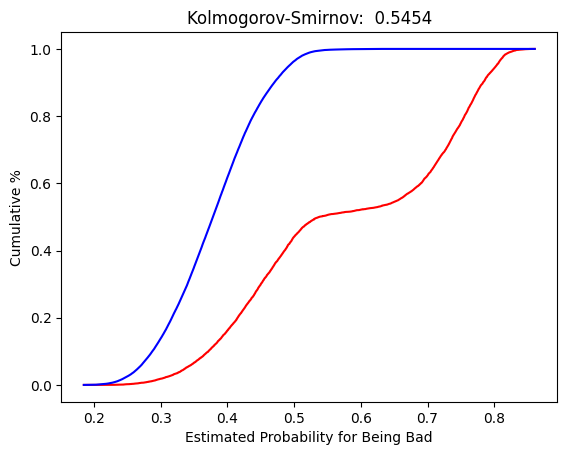

In [689]:
#menghitung skor Kolmogorov-Smirnov (KS) dan memvisualisasikannya dalam sebuah grafik
KS = max(df_actual_predicted['Cumulative Perc Good'] - df_actual_predicted['Cumulative Perc Bad'])

plt.plot(df_actual_predicted['y_pred_proba'], df_actual_predicted['Cumulative Perc Bad'], color='r')
plt.plot(df_actual_predicted['y_pred_proba'], df_actual_predicted['Cumulative Perc Good'], color='b')
plt.xlabel('Estimated Probability for Being Bad')
plt.ylabel('Cumulative %')
plt.title('Kolmogorov-Smirnov:  %0.4f' %KS)

Classification Report - Random Forest:
              precision    recall  f1-score   support

    Good (0)       0.95      0.96      0.96     83067
     Bad (1)       0.65      0.56      0.60     10190

    accuracy                           0.92     93257
   macro avg       0.80      0.76      0.78     93257
weighted avg       0.91      0.92      0.92     93257



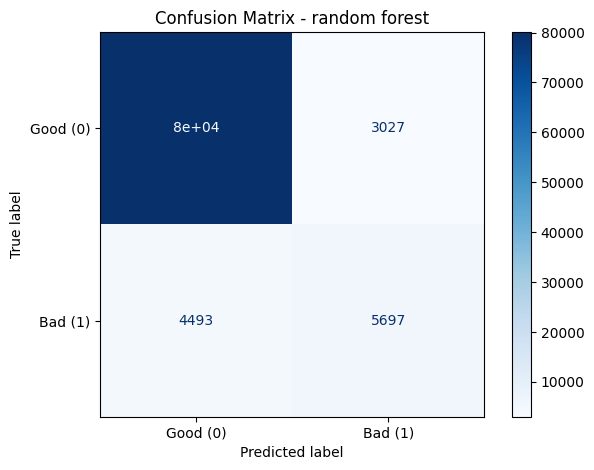

In [690]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix random forest
y_pred_lr = rfc.predict(X_test) # Changed 'lr' to 'rfc'

print('Classification Report - Random Forest:')
print(classification_report(y_test, y_pred_lr, target_names=['Good (0)', 'Bad (1)']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Good (0)', 'Bad (1)'])
disp_lr.plot(cmap='Blues')
plt.title('Confusion Matrix - random forest')
plt.tight_layout()
plt.show()

**MODEL REGRESI LOGISTIK**

In [691]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Inisiasi model Logistic Regression
model_logreg = LogisticRegression()

# Train model
model_logreg.fit(X_train, y_train)

# Prediksi menggunakan data test
y_pred_logreg = model_logreg.predict(X_test)

train_accuracy_logreg = model_logreg.score(X_train, y_train)
print("Train Accuracy:", train_accuracy_logreg)


Train Accuracy: 0.9393611203448534


In [692]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Prediksi pada data testing
y_pred_logreg = model_logreg.predict(X_test)

# Hitung metrik evaluasi
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

roc_auc_logreg = roc_auc_score(y_test, model_logreg.predict_proba(X_test)[:,1])

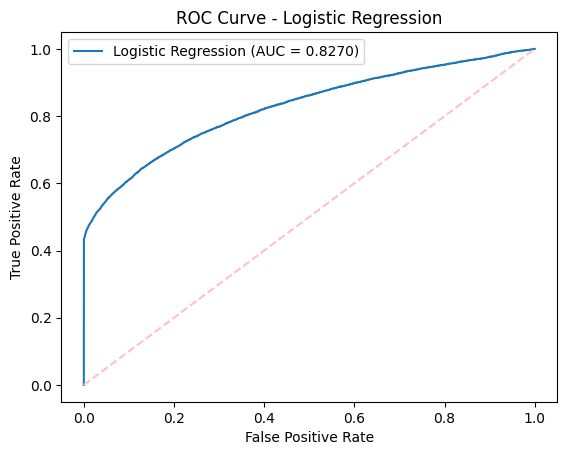

In [694]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Inisialisasi dan Training Model Logistic Regression
# Kita gunakan max_iter=1000 agar model punya cukup waktu untuk konvergen (mencapai titik optimal)
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_res, y_train_res)

# 2. Mendapatkan Probabilitas Prediksi untuk kelas 1 (Bad)
y_pred_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# 3. Menghitung FPR, TPR, dan AUC
fpr, tpr, tr = roc_curve(y_test, y_pred_proba_logreg)
auc = roc_auc_score(y_test, y_pred_proba_logreg)

# 4. Visualisasi ROC Curve
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.4f)' % auc)
plt.plot([0, 1], [0, 1], linestyle='--', color='PINK') # Garis bantu diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

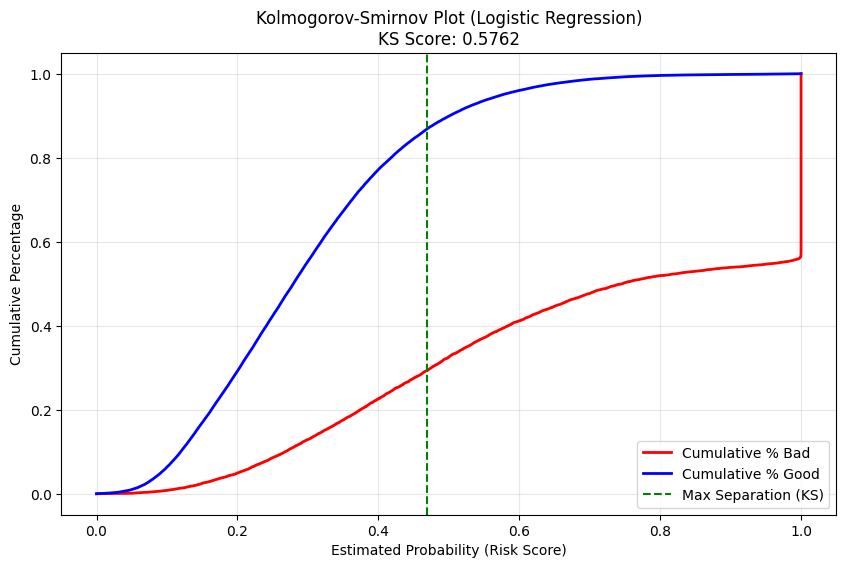

In [695]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train, y_train)
y_pred_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# 2. Membuat DataFrame evaluasi
df_logreg = pd.DataFrame({
    'y_actual': y_test.values,
    'y_pred_proba': y_pred_proba_logreg
})

# 3. Kalkulasi Distribusi Kumulatif
df_logreg = df_logreg.sort_values('y_pred_proba').reset_index(drop=True)

df_logreg['Cumulative N Population'] = df_logreg.index + 1
df_logreg['Cumulative N Bad'] = df_logreg['y_actual'].cumsum()
df_logreg['Cumulative N Good'] = df_logreg['Cumulative N Population'] - df_logreg['Cumulative N Bad']

# Menghitung persentase kumulatif (ECDF)
df_logreg['Cumulative Perc Bad'] = df_logreg['Cumulative N Bad'] / df_logreg['y_actual'].sum()
df_logreg['Cumulative Perc Good'] = df_logreg['Cumulative N Good'] / (len(df_logreg) - df_logreg['y_actual'].sum())

# 4. Menghitung Skor KS
# KS adalah selisih absolut maksimum antara CDF 'Good' dan 'Bad'
df_logreg['KS_Diff'] = abs(df_logreg['Cumulative Perc Good'] - df_logreg['Cumulative Perc Bad'])
KS_logreg = df_logreg['KS_Diff'].max()

# 5. Visualisasi
plt.figure(figsize=(10, 6))
plt.plot(df_logreg['y_pred_proba'], df_logreg['Cumulative Perc Bad'], color='r', label='Cumulative % Bad', linewidth=2)
plt.plot(df_logreg['y_pred_proba'], df_logreg['Cumulative Perc Good'], color='b', label='Cumulative % Good', linewidth=2)

# Menemukan titik KS untuk garis bantu vertikal
ks_pos = df_logreg.loc[df_logreg['KS_Diff'] == KS_logreg, 'y_pred_proba'].iloc[0]
plt.axvline(ks_pos, color='green', linestyle='--', label=f'Max Separation (KS)')

plt.xlabel('Estimated Probability (Risk Score)')
plt.ylabel('Cumulative Percentage')
plt.title(f'Kolmogorov-Smirnov Plot (Logistic Regression)\nKS Score: {KS_logreg:.4f}')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [696]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

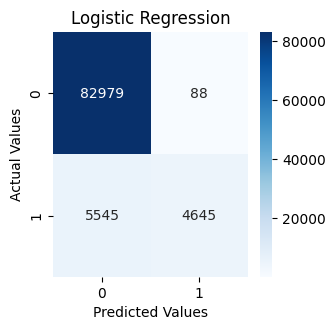

In [697]:
cm_list = [cm_logreg]
model_names = ['Logistic Regression']

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flatten()

for i in range(len(cm_list)):
    sns.heatmap(cm_list[i], annot=True, cmap='Blues', fmt='g', ax=axes[i])
    axes[i].set_title(model_names[i])
    axes[i].set_ylabel('Actual Values')
    axes[i].set_xlabel('Predicted Values')

# hapus subplot kosong
for j in range(len(cm_list), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Diperoleh performa model random forest yang dibangun adalah AUC = 0.8498 dan KS = 0.5454, sedangkan model regresi logistik adalah AUC=0.827 dan KS=0.5762 . Pada umumnya di dunia credit risk modelling, biasanya AUC > 0.7 dan KS>0.3 sudah termasuk performa yang baik.

# SARAN
*  Scorecard Development: Menggunakan Logistic Regression dengan pendekatan WoE dan IV untuk menciptakan model yang lebih mudah diinterpretasikan oleh sisi bisnis.
*   Advanced Modeling: Mencoba algoritma Boosting jika ingin mengejar akurasi dan AUC yang lebih tinggi.
*   Model Robustness: Melakukan Hyperparameter Tuning dan pengecekan overfitting secara berkala melalui perbandingan performa train vs test.
*  Refactoring Pipeline: Memperbaiki urutan preprocessing dengan melakukan pembagian data sebelum transformasi fitur untuk menjaga integritas pengujian.


